Project 2

Description: Project report 2 should naturally follow project report 1 on ”Data: Feature extraction, and
visualization” and cover what you have learned in the lectures and exercises of week 5 to 8 on
”Supervised learning: Classification and regression”. The report should therefore include two
02452 PROJECT 2 Fall 2025
sections. A section on regression and a section on classification. The report will be evaluated
based on how it addresses each of the questions asked below and an overall assessment of the
report quality


Importing Relevant Packages

In [9]:
# Import relevant packages
import numpy as np
import pandas as pd
from scipy.io import loadmat

import sklearn.linear_model as lm
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut
from sklearn.decomposition import PCA
from sklearn import model_selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

def setup_storage_for_experiment(K_outer, K_inner, num_hyperparams):
    # Setup storage for the optimal hyperparameters found from the inner CV
    optimal_hyperparameters = np.empty(K_outer)

    # Setup storage for model coefficients and errors for each experiment in all inner folds
    ws_inner = np.empty((M + 1, K_outer, K_inner, num_hyperparams))
    train_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))
    test_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))

    # Setup storage for model coefficients for each experiment in all outer folds
    ws_outer = {
        'not regularized': np.empty((M + 1, K_outer)),
        'regularized': np.empty((M + 1, K_outer))
    }
    # Setup storage for errors as a dictionary
    errors_outer = {
        'train': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        },
        'test': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        }
    }
    return optimal_hyperparameters, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer

def get_grid_points(x_min, x_max, y_min, y_max, delta=5e-3):
    # Create a grid of points with the specified resolution
    xx = np.arange(x_min, x_max, delta)
    yy = np.arange(y_min, y_max, delta)
    # Make a mesh-grid that spans the grid-range defined
    grid = np.stack(np.meshgrid(xx, yy))
    return grid, xx, yy

def plot_decision_boundary(predict_function, X, threshold=None, fig=None, cmap='RdBu_r'):
    # Set grid range based on the data
    grid_range = [X[:, 0].min(), X[:, 0].max(), X[:, 1].min(), X[:, 1].max()]  # [x_min, x_max, y_min, y_max]
    # Add 10% margin to the grid range to ensure points on the edge are included
    margin_x = 0.1 * (grid_range[1] - grid_range[0])
    margin_y = 0.1 * (grid_range[3] - grid_range[2])
    grid_range[0] -= margin_x
    grid_range[1] += margin_x
    grid_range[2] -= margin_y
    grid_range[3] += margin_y

    # Get grid points
    grid, xx, yy = get_grid_points(*grid_range, delta=5e-3)
    # Reshape grid to a list of points
    grid_points = torch.tensor(np.reshape(grid, (2, -1)).T, dtype=torch.float32)

    # Compute model predictions on the grid points (i.e. the probability of class 1)
    with torch.no_grad():  # No need to compute gradients for plotting
        grid_predictions = predict_function(grid_points)

    # Reshape the predictions back to the grid shape
    decision_boundary = np.reshape(grid_predictions, (len(yy), len(xx)))

    # Setup figure and axis for plotting
    if fig is None:
        fig = plt.figure(figsize=(6, 6))
    ax = fig.gca()

    # Plot the decision boundary
    img = ax.imshow(decision_boundary, extent=grid_range, origin='lower', cmap=cmap, alpha=0.5)
    fig.colorbar(img, ax=ax)
    if threshold is not None:
        ax.contour(grid[0], grid[1], decision_boundary, levels=[threshold], colors='k')
    ax.grid(False)
    ax.set_aspect('auto')

def print_regularization_results(errors):
    # Display results
    print("Linear regression without regularization:")
    print(f"- Training error: \t{errors['train']['not regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['not regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['not regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['not regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

    print("Regularized linear regression:")
    print(f"- Training error: \t{errors['train']['regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

def get_model(input_dim, hidden_dim, output_dim):
    ### BEGIN SOLUTION
    return torch.nn.Sequential(
        torch.nn.Linear(in_features=input_dim, out_features=hidden_dim, bias=True),     # Input layer
        torch.nn.Tanh(),                                                                # Activation function
        torch.nn.Linear(in_features=hidden_dim, out_features=output_dim, bias=True),    # Output layer
    )
    ### END SOLUTION

# Regression

## Part A

1. Explain what variable is predicted based on which other variables and what you hope to
accomplish by the regression. Mention your feature transformation choices such as one-ofK coding. Since we will use regularization momentarily, apply a feature transformation to
your data matrix X such that each column has mean 0 and standard deviation 1^1



In [10]:
# Loading the data
columns = [
    'Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

df = pd.read_fwf("data/ecoli.data", header=None, names=columns)

# Define predictors (X) and target (y)
X = df.drop(columns=['mcg', 'class', 'Sequence Name'])
y = df['mcg']

#Scaling X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = X_scaled
N, M = X_scaled.shape
print(X_scaled)
print(columns)

[[-1.41953086 -0.17514236 -0.05463584  0.49078096 -1.20771743 -0.7160837 ]
 [-0.67596708 -0.17514236 -0.05463584  0.32710612 -0.69711074 -0.28566488]
 [-0.67596708 -0.17514236 -0.05463584 -0.08208098 -0.60427317 -0.19001625]
 ...
 [ 0.67596708 -0.17514236 -0.05463584 -0.49126808 -0.51143559 -0.57261076]
 [ 0.74356378 -0.17514236 -0.05463584 -0.65494292 -0.37217922 -0.62043507]
 [ 1.62232098 -0.17514236 -0.05463584 -1.55515454  0.13842746  0.09692964]]
['Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class']


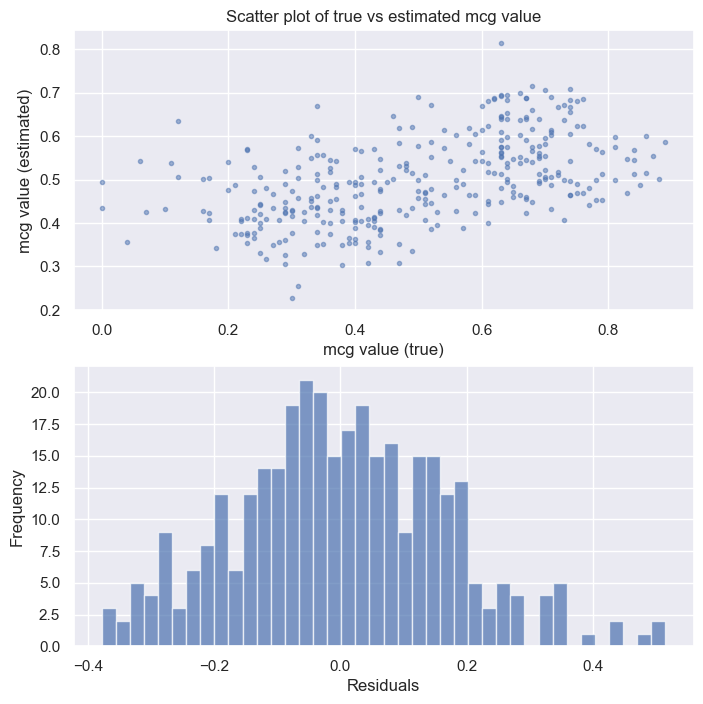

Estimated parameters:
gvh: 0.079
alm2: 0.633

MSE: 0.028


In [11]:
X = df[['gvh','alm2']]
y = df['mcg']

# Fit the linear regression model
model = lm.LinearRegression(fit_intercept=True)
model.fit(X, y)
# Estimated parameters (intercept and coefficients)
w_star = np.hstack([model.intercept_, model.coef_.flatten()])  # Estimated parameters

# Predict alcohol content
y_est = model.predict(X)
# Calculate residuals
residual = y_est - y

### END SOLUTION

# Display scatter plot and histogram of residuals
fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs[0].scatter(y, y_est, marker='.', alpha=0.5)
axs[0].set_xlabel("mcg value (true)")
axs[0].set_ylabel("mcg value (estimated)")
axs[0].set_title("Scatter plot of true vs estimated mcg value")
axs[1].hist(residual, bins=40, alpha=0.7)
axs[1].set_xlabel("Residuals")
axs[1].set_ylabel("Frequency")
plt.show()

# Estimated parameters, and their attribute names
print("\033[1mEstimated parameters:\033[0;0m")      # Bold text for emphasis
for i, name in enumerate(X.columns):
    print(f"{name}: {w_star[i].item():.3f}")

print(f"\nMSE: {np.mean(residual**2):.3f}")

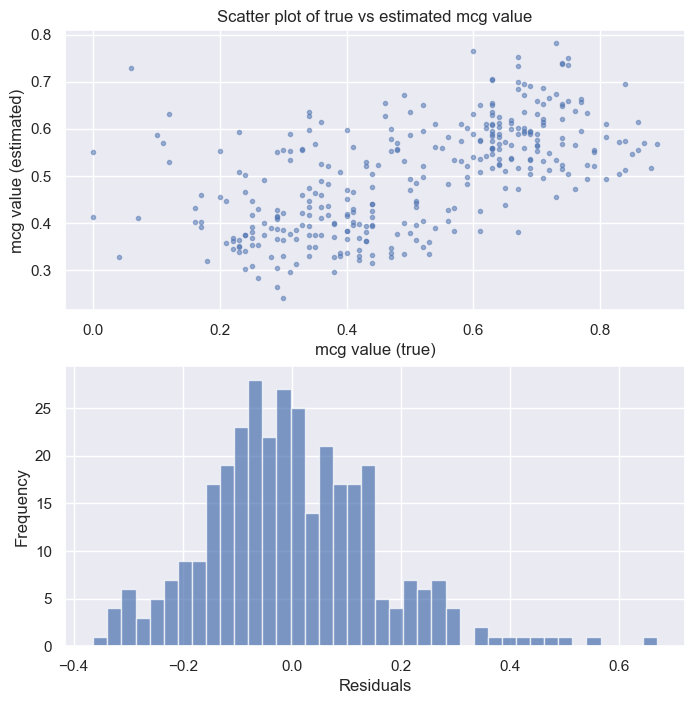

Estimated parameters:
gvh: -0.166
lip: 0.458
chg: 0.129
aac: 0.324
alm1: 0.183
alm2: 0.389

MSE: 0.025


In [12]:
X = df.drop(columns=['mcg', 'class', 'Sequence Name'])
y = df['mcg']

# Fit the linear regression model
model = lm.LinearRegression(fit_intercept=True)
model.fit(X, y)
# Estimated parameters (intercept and coefficients)
w_star = np.hstack([model.intercept_, model.coef_.flatten()])  # Estimated parameters

# Predict alcohol content
y_est = model.predict(X)
# Calculate residuals
residual = y_est - y

### END SOLUTION

# Display scatter plot and histogram of residuals
fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs[0].scatter(y, y_est, marker='.', alpha=0.5)
axs[0].set_xlabel("mcg value (true)")
axs[0].set_ylabel("mcg value (estimated)")
axs[0].set_title("Scatter plot of true vs estimated mcg value")
axs[1].hist(residual, bins=40, alpha=0.7)
axs[1].set_xlabel("Residuals")
axs[1].set_ylabel("Frequency")
plt.show()

# Estimated parameters, and their attribute names
print("\033[1mEstimated parameters:\033[0;0m")      # Bold text for emphasis
for i, name in enumerate(X.columns):
    print(f"{name}: {w_star[i].item():.3f}")

print(f"\nMSE: {np.mean(residual**2):.3f}")

2. Introduce a regularization parameter λ as discussed in 14 of the lecture notes, and estimate
the generalization error for different values of λ. Specifically, choose a reasonable range of
values of λ (ideally one where the generalization error first drop and then increases), and
for each value use K = 10 fold cross-validation (algorithm 5) to estimate the generalization
error. Include a figure of the estimated generalization error as a function of λ in the report
and briefly discuss the result

Optimal λ = 31.623
Test MSE (optimal λ) = 0.0261


,Feature,Weight
0,gvh,0.067192
4,alm1,0.063401
3,aac,0.021350
1,lip,0.013420
2,chg,0.008185
5,alm2,-0.013671


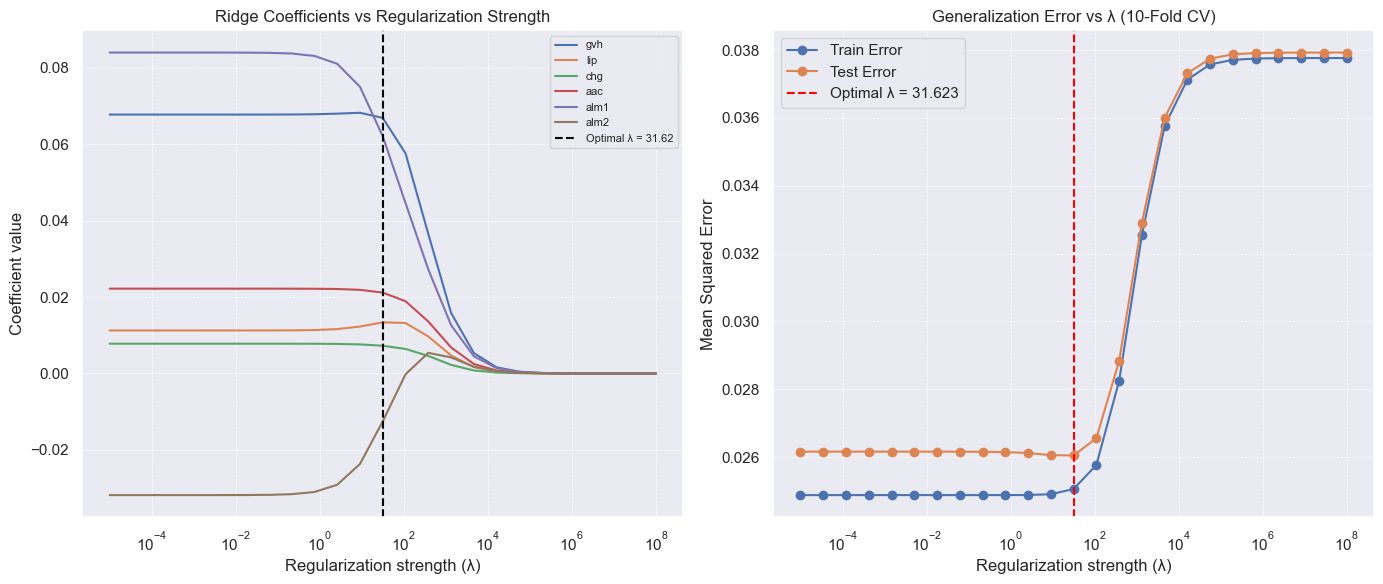

In [13]:
# --- Data setup ---
X = X_scaled

# Set random seed for reproducibility
np.random.seed(1234)

# Define 10-fold cross-validation
K = 10
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Define range of regularization strengths λ (log-spaced)
lambdas = np.logspace(-5, 8, 25)

# Storage
train_errors = np.zeros(len(lambdas))
test_errors = np.zeros(len(lambdas))
coefficients = np.zeros((len(lambdas), X.shape[1]))

# --- Algorithm 5: K-fold CV for each λ ---
for i, lam in enumerate(lambdas):
    ridge = Ridge(alpha=lam)
    fold_train_errors = []
    fold_test_errors = []
    fold_coefs = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        ridge.fit(X_train, y_train)
        y_train_pred = ridge.predict(X_train)
        y_test_pred = ridge.predict(X_test)

        fold_train_errors.append(mean_squared_error(y_train, y_train_pred))
        fold_test_errors.append(mean_squared_error(y_test, y_test_pred))
        fold_coefs.append(ridge.coef_)

    # Store mean results across folds
    train_errors[i] = np.mean(fold_train_errors)
    test_errors[i] = np.mean(fold_test_errors)
    coefficients[i, :] = np.mean(fold_coefs, axis=0)

# --- Find optimal λ ---
opt_idx = np.argmin(test_errors)
opt_lambda = lambdas[opt_idx]
opt_test_error = test_errors[opt_idx]

# --- Refit on full dataset using optimal λ ---
final_model = Ridge(alpha=opt_lambda)
final_model.fit(X, y)

# --- Display feature weights ---
feature_names = df.drop(columns=['mcg', 'class', 'Sequence Name']).columns
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': final_model.coef_
}).sort_values(by='Weight', ascending=False)

print(f"Optimal λ = {opt_lambda:.3f}")
print(f"Test MSE (optimal λ) = {opt_test_error:.4f}")
display(weights_df)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Coefficient shrinkage
for i, feature in enumerate(feature_names):
    axes[0].semilogx(lambdas, coefficients[:, i], label=feature)

axes[0].axvline(opt_lambda, color='black', linestyle='--', label=f"Optimal λ = {opt_lambda:.2f}")
axes[0].set_xlabel("Regularization strength (λ)")
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Ridge Coefficients vs Regularization Strength")
axes[0].legend(fontsize=8)
axes[0].grid(True, which="both", linestyle='--', linewidth=0.5)

# Right: Train/Test MSE vs λ (Generalization Error)
axes[1].semilogx(lambdas, train_errors, label="Train Error", marker='o')
axes[1].semilogx(lambdas, test_errors, label="Test Error", marker='o')
axes[1].axvline(opt_lambda, color='red', linestyle='--', label=f"Optimal λ = {opt_lambda:.3f}")
axes[1].set_xlabel("Regularization strength (λ)")
axes[1].set_ylabel("Mean Squared Error")
axes[1].set_title("Generalization Error vs λ (10-Fold CV)")
axes[1].legend()
axes[1].grid(True, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


3. Explain how the output, y, of the linear model with the lowest generalization error (as
determined in the previous question) is computed for a given input x. What is the effect
of an individual attribute in x on the output, y, of the linear model? Does the effect of
individual attributes make sense based on your understanding of the problem?

Regression, part b: In this section, we will compare three models: the regularized linear regression model from the previous section, an artificial neural network (ANN) and a baseline. We
are interested in two questions: Is one model better than the other? Is either model better than
a trivial baseline?. We will attempt to answer these questions with two-level cross-validation.


1. Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use
2-level cross-validation to compare the models with K1 = K2 = 10 folds2
. As a baseline
model, we will apply a linear regression model with no features, i.e. it computes the mean
of y on the training data, and use this value to predict y on the test data.
Make sure you can fit an ANN model to the data. As complexity-controlling parameter
for the ANN, we will use the number of hidden units3 h. Based on a few test-runs, select
a reasonable range of values for h (which should include h = 1), and describe the range of
values you will use for h and λ.

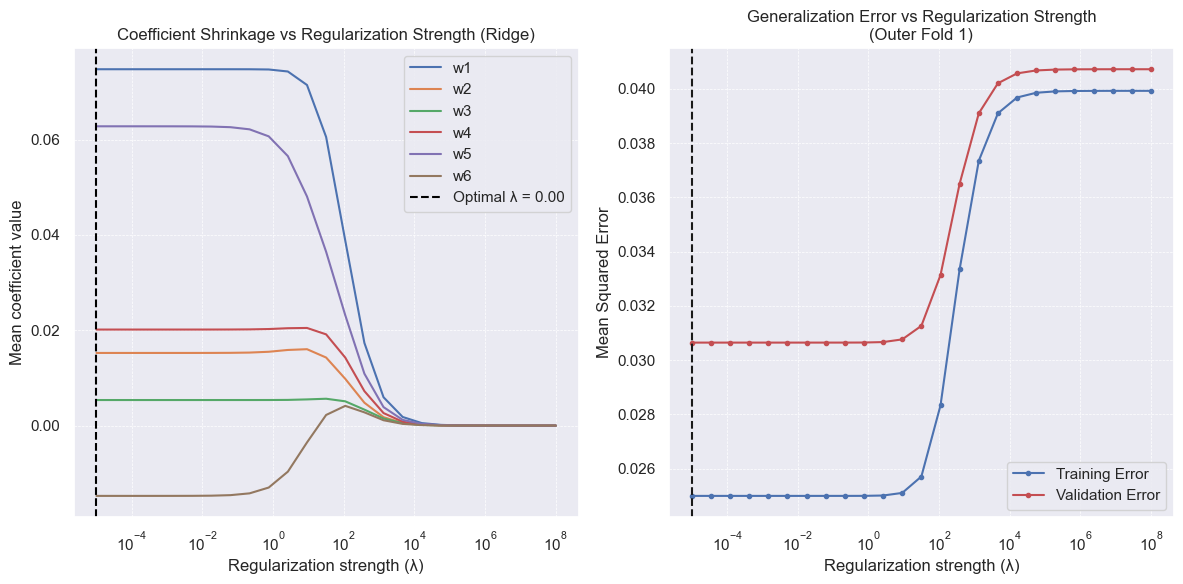

c:\Users\Change\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Change\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Change\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Outer Fold,Ridge λ,Ridge Test MSE,ANN h*,ANN α*,ANN Test MSE,Baseline Test MSE
0,1,0.00001,0.024336,5,1,0.024239,0.035818
1,2,0.00001,0.027740,3,1,0.474328,0.040945


In [ ]:
X = X_scaled
y = y.to_numpy()

np.random.seed(1234)

# --- Cross-validation setup ---
K_outer = 10
K_inner = 10

CV_outer = KFold(K_outer, shuffle=True, random_state=1234)
CV_inner = KFold(K_inner, shuffle=True, random_state=1234)

# --- Hyperparameters ---
lambdas = np.logspace(-5, 8, 25)  # Ridge regularization
hidden_units = [1, 3, 5]          # ANN hidden layer sizes
alphas = [1e-4, 1e-2, 1]          # ANN regularization strengths

results = []  # store model results

# -------------------------------------------------------------
# OUTER CROSS-VALIDATION LOOP
# -------------------------------------------------------------
for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(CV_outer.split(X, y)):
    X_train_outer, X_test_outer = X[outer_train_idx], X[outer_test_idx]
    y_train_outer, y_test_outer = y[outer_train_idx], y[outer_test_idx]

    # ---------- INNER LOOP FOR ANN ----------
    inner_errors = np.zeros((len(hidden_units), len(alphas)))
    for i, h in enumerate(hidden_units):
        for j, alpha in enumerate(alphas):
            fold_errors = []
            for inner_train_idx, inner_val_idx in CV_inner.split(X_train_outer):
                X_train_inner, X_val_inner = X_train_outer[inner_train_idx], X_train_outer[inner_val_idx]
                y_train_inner, y_val_inner = y_train_outer[inner_train_idx], y_train_outer[inner_val_idx]

                ann = MLPRegressor(hidden_layer_sizes=(h,),
                                   alpha=alpha,
                                   max_iter=2500,
                                   early_stopping=True,
                                   random_state=1234)
                ann.fit(X_train_inner, y_train_inner)
                y_val_pred = ann.predict(X_val_inner)
                fold_errors.append(mean_squared_error(y_val_inner, y_val_pred))
            inner_errors[i, j] = np.mean(fold_errors)

    # Find best (h, α)
    i_opt, j_opt = np.unravel_index(np.argmin(inner_errors), inner_errors.shape)
    h_opt = hidden_units[i_opt]
    alpha_opt = alphas[j_opt]

    # Train final ANN
    ann_final = MLPRegressor(hidden_layer_sizes=(h_opt,),
                             alpha=alpha_opt,
                             max_iter=2500,
                             early_stopping=True,
                             random_state=1234)
    ann_final.fit(X_train_outer, y_train_outer)
    y_pred_ann = ann_final.predict(X_test_outer)
    ann_test_mse = mean_squared_error(y_test_outer, y_pred_ann)

    # ---------- BASELINE ----------
    baseline_pred = np.ones_like(y_test_outer) * y_train_outer.mean()
    baseline_mse = mean_squared_error(y_test_outer, baseline_pred)

    # ---------- RIDGE ----------
    inner_ridge_train_errors = []
    inner_ridge_val_errors = []
    inner_ridge_coefs = []

    for lam in lambdas:
        fold_train_errors = []
        fold_val_errors = []
        fold_coefs = []

        for inner_train_idx, inner_val_idx in CV_inner.split(X_train_outer):
            X_train_inner, X_val_inner = X_train_outer[inner_train_idx], X_train_outer[inner_val_idx]
            y_train_inner, y_val_inner = y_train_outer[inner_train_idx], y_train_outer[inner_val_idx]

            ridge = Ridge(alpha=lam)
            ridge.fit(X_train_inner, y_train_inner)
            y_val_pred = ridge.predict(X_val_inner)
            y_train_pred = ridge.predict(X_train_inner)

            fold_train_errors.append(mean_squared_error(y_train_inner, y_train_pred))
            fold_val_errors.append(mean_squared_error(y_val_inner, y_val_pred))
            fold_coefs.append(ridge.coef_)

        inner_ridge_train_errors.append(np.mean(fold_train_errors))
        inner_ridge_val_errors.append(np.mean(fold_val_errors))
        inner_ridge_coefs.append(np.mean(fold_coefs, axis=0))

    # Convert to arrays
    inner_ridge_train_errors = np.array(inner_ridge_train_errors)
    inner_ridge_val_errors = np.array(inner_ridge_val_errors)
    inner_ridge_coefs = np.array(inner_ridge_coefs)

    # Find optimal λ for this outer fold
    opt_lambda = lambdas[np.argmin(inner_ridge_val_errors)]

    # Train Ridge with best λ on full outer training set
    ridge_final = Ridge(alpha=opt_lambda)
    ridge_final.fit(X_train_outer, y_train_outer)
    ridge_pred = ridge_final.predict(X_test_outer)
    ridge_test_mse = mean_squared_error(y_test_outer, ridge_pred)

    # Store results
    results.append({
        "Outer Fold": outer_fold + 1,
        "Ridge λ": opt_lambda,
        "Ridge Test MSE": ridge_test_mse,
        "ANN h*": h_opt,
        "ANN α*": alpha_opt,
        "ANN Test MSE": ann_test_mse,
        "Baseline Test MSE": baseline_mse
    })

    # -------------------------------------------------------------
    # PLOT (only for one outer fold to save time)
    # -------------------------------------------------------------
    if outer_fold == 5:
        plt.figure(figsize=(12, 6))

        # Coefficients vs λ
        plt.subplot(1, 2, 1)
        plt.title("Coefficient Shrinkage vs Regularization Strength (Ridge)")
        for i in range(inner_ridge_coefs.shape[1]):
            plt.semilogx(lambdas, inner_ridge_coefs[:, i], label=f"w{i+1}")
        plt.axvline(opt_lambda, color='black', linestyle='--', label=f"Optimal λ = {opt_lambda:.2f}")
        plt.xlabel("Regularization strength (λ)")
        plt.ylabel("Mean coefficient value")
        plt.legend(loc='best')
        plt.grid(True, which="both", linestyle='--', linewidth=0.5)

        # Training/Validation error vs λ
        plt.subplot(1, 2, 2)
        plt.title(f"Generalization Error vs Regularization Strength\n(Outer Fold {outer_fold + 1})")
        plt.semilogx(lambdas, inner_ridge_train_errors, 'b.-', label="Training Error")
        plt.semilogx(lambdas, inner_ridge_val_errors, 'r.-', label="Validation Error")
        plt.axvline(opt_lambda, color='k', linestyle='--')
        plt.xlabel("Regularization strength (λ)")
        plt.ylabel("Mean Squared Error")
        plt.legend()
        plt.grid(True, which="both", linestyle='--', linewidth=0.5)

        plt.tight_layout()
        plt.show()

# -------------------------------------------------------------
# VIEW RESULTS
# -------------------------------------------------------------
results_df = pd.DataFrame(results)
display(results_df)


2. Produce a table akin to Table 1 using two-level cross-validation (algorithm 6 in the lecture
notes). The table shows, for each of the K1 = 10 folds i, the optimal value of the number
of hidden units and regularization strength (h
∗
i
and λ
∗
i
respectively) as found after each
inner loop, as well as the estimated generalization errors E
test
i by evaluating on Dtest
i
. It
also includes the baseline test error, also evaluated on Dtest
i
. Importantly, you must re-use
the train/test splits D
par
i
, Dtest
i
for all three methods to allow statistical comparison (see
next section).


3. Statistically evaluate if there is a significant performance difference between the fitted
ANN, linear regression model and baseline using the methods described in ??. These
comparisons will be made pairwise (ANN vs. linear regression; ANN vs. baseline; linear
regression vs. baseline). We will allow some freedom in what test to choose. Therefore,
choose either:
setup I (11.3): Use the paired t-test described in 11.3.4
setup II (11.4): Use the method described in 11.4.1)
Include p-values and confidence intervals for the three pairwise tests in your report and
conclude on the results: Is one model better than the other? Are the two models better
than the baseline? Are some of the models identical? What recommendations would you
make based on what you’ve learned?


In [17]:
def correlated_ttest(r, rho, alpha=0.05):
    """
    Perform a correlated t-test to compare two models under Setup II.

    Parameters:
    - r (array-like): Array of performance differences across folds (e.g. r_j = error_A - error_B)
    - rho (float): Correlation coefficient between folds (typically 1/K for K-fold CV)
    - alpha (float, optional): Significance level (default: 0.05)

    Returns:
    - p (float): p-value of the test
    - CI (tuple): Confidence interval for the mean difference
    """

    r = np.array(r)
    r_hat = np.mean(r)
    s_hat = np.std(r, ddof=1)
    J = len(r)

    # Adjusted standard deviation accounting for correlation
    sigma_tilde = s_hat * np.sqrt((1 / J) + (rho / (1 - rho)))

    # Confidence interval
    CI = st.t.interval(1 - alpha, df=J - 1, loc=r_hat, scale=sigma_tilde)

    # Two-sided p-value
    p = 2 * st.t.cdf(-np.abs(r_hat) / sigma_tilde, df=J - 1)

    return r_hat, CI, p


In [18]:
ridge_errors = np.array([
    0.030257, 0.021718, 0.019305, 0.031407, 0.017971,
    0.023452, 0.026090, 0.029498, 0.019245, 0.042203
])

ann_errors = np.array([
    0.033794, 0.065976, 0.021084, 0.039021, 0.027214,
    0.028021, 1.624112, 0.053811, 0.019918, 0.064520
])

baseline_errors = np.array([
    0.046073, 0.027803, 0.030460, 0.044185, 0.029292,
    0.031965, 0.037501, 0.050590, 0.041005, 0.042071
])

rho = 1 / 10  # 10-fold correlation assumption

comparisons = {
    "ANN vs Ridge": ann_errors - ridge_errors,
    "ANN vs Baseline": ann_errors - baseline_errors,
    "Ridge vs Baseline": ridge_errors - baseline_errors
}

for name, diff in comparisons.items():
    diff = diff[~np.isnan(diff)]  # remove NaNs
    r_hat, CI, p = correlated_ttest(diff, rho)
    print(f"{name}:")
    print(f"  Mean difference = {r_hat:.4f}")
    print(f"  95% CI = [{CI[0]:.4f}, {CI[1]:.4f}]")
    print(f"  p-value = {p:.4f}\n")


ANN vs Ridge:
  Mean difference = 0.1716
  95% CI = [-0.3495, 0.6927]
  p-value = 0.4752

ANN vs Baseline:
  Mean difference = 0.1597
  95% CI = [-0.3618, 0.6811]
  p-value = 0.5060

Ridge vs Baseline:
  Mean difference = -0.0120
  95% CI = [-0.0188, -0.0051]
  p-value = 0.0033



Regression, part b: In this section, we will compare three models: the regularized linear regression model from the previous section, an artificial neural network (ANN) and a baseline. We
are interested in two questions: Is one model better than the other? Is either model better than
a trivial baseline?. We will attempt to answer these questions with two-level cross-validation.


1. Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use
2-level cross-validation to compare the models with K1 = K2 = 10 folds2
. As a baseline
model, we will apply a linear regression model with no features, i.e. it computes the mean
of y on the training data, and use this value to predict y on the test data.
Make sure you can fit an ANN model to the data. As complexity-controlling parameter
for the ANN, we will use the number of hidden units3 h. Based on a few test-runs, select
a reasonable range of values for h (which should include h = 1), and describe the range of
values you will use for h and λ.

# Classification

## Retrieve and klargør data


In [19]:
# Loading the data
columns = [
    'Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

df = pd.read_fwf("data/ecoli.data", header=None, names=columns)

# Define predictors (X) and target (y)
X = df.drop(columns=['class', 'Sequence Name'])
y = df['class']


#Scaling X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
N, M = X_scaled.shape

# Ensure X is a numpy array for proper indexing (not a DataFrame)
X = np.asarray(X_scaled)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(f"Converted class labels to integers. Class mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

print(X_scaled)
print(columns)

Converted class labels to integers. Class mapping: {'cp': 0, 'im': 1, 'mL': 2, 'mS': 3, 'mU': 4, 'om': 5, 'pp': 6}
[[-0.0517614  -1.41953086 -0.17514236 ...  0.49078096 -1.20771743
  -0.7160837 ]
 [-2.21287637 -0.67596708 -0.17514236 ...  0.32710612 -0.69711074
  -0.28566488]
 [ 0.30842443 -0.67596708 -0.17514236 ... -0.08208098 -0.60427317
  -0.19001625]
 ...
 [ 0.56570002  0.67596708 -0.17514236 ... -0.49126808 -0.51143559
  -0.57261076]
 [ 0.46278978  0.74356378 -0.17514236 ... -0.65494292 -0.37217922
  -0.62043507]
 [ 1.23461656  1.62232098 -0.17514236 ... -1.55515454  0.13842746
   0.09692964]]
['Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class']


### 

## Multi class classification (2-layer cross validation)

In [20]:
# Ensure X and y are numpy arrays for proper indexing
X = np.asarray(X_scaled) if 'X_scaled' in locals() or 'X_scaled' in globals() else np.asarray(X)
if hasattr(y, 'to_numpy'):
    y = y.to_numpy()
else:
    y = np.asarray(y)

# Set random seed for reproducibility
np.random.seed(1234)

# Create crossvalidation partition for model evaluation
K_outer = 10
CV_outer = model_selection.KFold(K_outer, shuffle=True)

# Create crossvalidation partition for hyperparameter tuning
K_inner = 10
CV_inner = model_selection.KFold(K_inner, shuffle=True)

# Values of regularization parameter lambda to test in the inner loop (for logistic regression)
lambdas = np.logspace(-10, 10, 50)

# Values of k to test in the inner loop (for KNN)
k_values = np.arange(1, 21, dtype=int)  # k from 1 to 20

# Setup storage for the experiment
# For logistic regression
lr_errors_inner = {'train': np.empty((K_outer, K_inner, len(lambdas))), 
                   'test': np.empty((K_outer, K_inner, len(lambdas)))}
optimal_lambdas = np.empty(K_outer)

# For KNN
knn_errors_inner = {'train': np.empty((K_outer, K_inner, len(k_values))), 
                    'test': np.empty((K_outer, K_inner, len(k_values)))}
optimal_k_values = np.empty(K_outer, dtype=int)

# For outer fold results
results = {
    'logistic_regression': {
        'train_error': np.empty(K_outer),
        'test_error': np.empty(K_outer),
        'optimal_lambda': np.empty(K_outer)
    },
    'knn': {
        'train_error': np.empty(K_outer),
        'test_error': np.empty(K_outer),
        'optimal_k': np.empty(K_outer)
    },
    'baseline': {
        'train_error': np.empty(K_outer),
        'test_error': np.empty(K_outer)
    }
}

# Run two-layer cross-validation
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(CV_outer.split(X, y)):
    # Extract training and test set for the current outer CV fold
    # Convert to numpy arrays to ensure proper positional indexing (not label-based)
    X_train_outer = np.asarray(X[outer_train_index])
    y_train_outer = np.asarray(y[outer_train_index])
    X_test_outer = np.asarray(X[outer_test_index])
    y_test_outer = np.asarray(y[outer_test_index])

    # Loop over inner cross-validation folds
    for inner_fold_idx, (inner_train_index, inner_test_index) in enumerate(CV_inner.split(X_train_outer, y_train_outer)):

        # Extract training and validation set for current inner CV fold
        # Convert to numpy arrays to ensure proper positional indexing (not label-based)
        X_train_inner = np.asarray(X_train_outer[inner_train_index])
        y_train_inner = np.asarray(y_train_outer[inner_train_index])
        X_test_inner = np.asarray(X_train_outer[inner_test_index])
        y_test_inner = np.asarray(y_train_outer[inner_test_index])

        # Compute the mean and standard deviation of the inner training data split, then standardize training and test sets
        # YOUR CODE HERE
        mean_inner = X_train_inner.mean(axis=0)
        std_inner = X_train_inner.std(axis=0)
        # Avoid division by zero
        std_inner[std_inner == 0] = 1e-12
        X_train_inner = (X_train_inner - mean_inner) / std_inner
        X_test_inner = (X_test_inner - mean_inner) / std_inner

        # Hyperparameter tuning for Logistic Regression
        for lambda_idx, regularization_strength in enumerate(lambdas):
            # Use softmax (multinomial) logistic regression for multi-class classification
            # Note: C = 1/lambda in sklearn (inverse relationship)
            model_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0/regularization_strength, max_iter=100000, random_state=1234)
            model_lr.fit(X_train_inner, y_train_inner)
            
            # Compute and store the training and validation error (0-1 loss: 1 if misclassified, 0 if correct)
            y_train_inner_pred_lr = model_lr.predict(X_train_inner)
            y_test_inner_pred_lr = model_lr.predict(X_test_inner)
            lr_errors_inner['train'][outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean(y_train_inner != y_train_inner_pred_lr)
            lr_errors_inner['test'][outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean(y_test_inner != y_test_inner_pred_lr)
        
        # Hyperparameter tuning for KNN
        for k_idx, k in enumerate(k_values):
            model_knn = KNeighborsClassifier(n_neighbors=k)
            model_knn.fit(X_train_inner, y_train_inner)
            
            # Compute and store the training and validation error (0-1 loss: 1 if misclassified, 0 if correct)
            y_train_inner_pred_knn = model_knn.predict(X_train_inner)
            y_test_inner_pred_knn = model_knn.predict(X_test_inner)
            knn_errors_inner['train'][outer_fold_idx, inner_fold_idx, k_idx] = np.mean(y_train_inner != y_train_inner_pred_knn)
            knn_errors_inner['test'][outer_fold_idx, inner_fold_idx, k_idx] = np.mean(y_test_inner != y_test_inner_pred_knn)
    
    # Determine the optimal hyperparameters from the inner folds
    # Optimal lambda for logistic regression
    optimal_lambda_idx = np.argmin(np.mean(lr_errors_inner['test'][outer_fold_idx], axis=0))
    optimal_lambda = lambdas[optimal_lambda_idx]
    optimal_lambdas[outer_fold_idx] = optimal_lambda
    
    # Optimal k for KNN
    optimal_k_idx = np.argmin(np.mean(knn_errors_inner['test'][outer_fold_idx], axis=0))
    optimal_k = k_values[optimal_k_idx]
    optimal_k_values[outer_fold_idx] = optimal_k

    # Compute the mean and standard deviation of the outer training data split, then standardize the training and test sets
    # YOUR CODE HERE
    mean_outer = X_train_outer.mean(axis=0)
    std_outer = X_train_outer.std(axis=0)
    # Avoid division by zero
    std_outer[std_outer == 0] = 1e-12
    X_train_outer = (X_train_outer - mean_outer) / std_outer
    X_test_outer = (X_test_outer - mean_outer) / std_outer

    # Evaluate Logistic Regression with optimal lambda on outer test set
    model_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0/optimal_lambda, max_iter=100000, random_state=1234)
    model_lr.fit(X_train_outer, y_train_outer)
    y_train_outer_pred_lr = model_lr.predict(X_train_outer)
    y_test_outer_pred_lr = model_lr.predict(X_test_outer)
    results['logistic_regression']['train_error'][outer_fold_idx] = np.mean(y_train_outer != y_train_outer_pred_lr)
    results['logistic_regression']['test_error'][outer_fold_idx] = np.mean(y_test_outer != y_test_outer_pred_lr)
    results['logistic_regression']['optimal_lambda'][outer_fold_idx] = optimal_lambda

    # Evaluate KNN with optimal k on outer test set
    model_knn = KNeighborsClassifier(n_neighbors=optimal_k)
    model_knn.fit(X_train_outer, y_train_outer)
    y_train_outer_pred_knn = model_knn.predict(X_train_outer)
    y_test_outer_pred_knn = model_knn.predict(X_test_outer)
    results['knn']['train_error'][outer_fold_idx] = np.mean(y_train_outer != y_train_outer_pred_knn)
    results['knn']['test_error'][outer_fold_idx] = np.mean(y_test_outer != y_test_outer_pred_knn)
    results['knn']['optimal_k'][outer_fold_idx] = optimal_k

    # Evaluate Baseline (predict most common class)
    most_common_class = np.bincount(y_train_outer.astype(int)).argmax()
    baseline_train_pred = np.full(len(y_train_outer), most_common_class)
    baseline_test_pred = np.full(len(y_test_outer), most_common_class)
    results['baseline']['train_error'][outer_fold_idx] = np.mean(y_train_outer != baseline_train_pred)
    results['baseline']['test_error'][outer_fold_idx] = np.mean(y_test_outer != baseline_test_pred)

# Create results dataframe
results_df = pd.DataFrame({
    'Outer_Fold': range(1, K_outer + 1),
    'LR_Train_Error': results['logistic_regression']['train_error'],
    'LR_Test_Error': results['logistic_regression']['test_error'],
    'LR_Optimal_Lambda': results['logistic_regression']['optimal_lambda'],
    'KNN_Train_Error': results['knn']['train_error'],
    'KNN_Test_Error': results['knn']['test_error'],
    'KNN_Optimal_k': results['knn']['optimal_k'],
    'Baseline_Train_Error': results['baseline']['train_error'],
    'Baseline_Test_Error': results['baseline']['test_error']
})

# Display the results dataframe
print("Cross-Validation Results Summary:")
print("=" * 80)
display(results_df)

print("\nMean Errors Across All Outer Folds:")
print("-" * 80)
print(f"Logistic Regression - Train: {results_df['LR_Train_Error'].mean():.4f}, Test: {results_df['LR_Test_Error'].mean():.4f}")
print(f"KNN - Train: {results_df['KNN_Train_Error'].mean():.4f}, Test: {results_df['KNN_Test_Error'].mean():.4f}")
print(f"Baseline - Train: {results_df['Baseline_Train_Error'].mean():.4f}, Test: {results_df['Baseline_Test_Error'].mean():.4f}")
print(f"\nMean Optimal Lambda: {results_df['LR_Optimal_Lambda'].mean():.4f}")
print(f"Mean Optimal k: {results_df['KNN_Optimal_k'].mean():.1f}")

c:\Users\Change\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Change\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Change\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Change\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

KeyboardInterrupt: 

## Plots

In [ ]:
def correlated_ttest(r, rho, alpha=0.05):
    """
    Perform a correlated t-test to compare two models under Setup II.

    Parameters:
    - r (array-like): Array of performance differences across folds (e.g. r_j = error_A - error_B)
    - rho (float): Correlation coefficient between folds (typically 1/K for K-fold CV)
    - alpha (float, optional): Significance level (default: 0.05)

    Returns:
    - r_hat (float): Mean difference
    - CI (tuple): Confidence interval for the mean difference
    - p (float): p-value of the test
    """

    # Convert to numpy array, ensuring it's 1D
    r = np.asarray(r).flatten()
    r_hat = np.mean(r)
    s_hat = np.std(r, ddof=1)
    J = len(r)

    # Check for valid input
    if J < 2:
        raise ValueError(f"Need at least 2 folds, got {J}")
    
    if np.isnan(s_hat) or s_hat == 0:
        # If all differences are the same, return appropriate values
        if s_hat == 0:
            CI = (r_hat, r_hat)  # No uncertainty if all values are the same
            p = 1.0 if r_hat == 0 else 0.0  # p=1 if no difference, p=0 if there's a difference but no variance
            return r_hat, CI, p
        else:
            raise ValueError("Standard deviation is NaN")

    # Adjusted standard deviation accounting for correlation
    sigma_tilde = s_hat * np.sqrt((1 / J) + (rho / (1 - rho)))

    # Handle edge case where sigma_tilde might be invalid
    if np.isnan(sigma_tilde) or sigma_tilde <= 0:
        CI = (np.nan, np.nan)
        p = np.nan
        return r_hat, CI, p

    # Confidence interval
    CI = st.t.interval(1 - alpha, df=J - 1, loc=r_hat, scale=sigma_tilde)

    # Two-sided p-value
    p = 2 * st.t.cdf(-np.abs(r_hat) / sigma_tilde, df=J - 1)

    return r_hat, CI, p


# Calculate performance differences (remove list brackets to pass Series directly)
r_knn_lr = results_df['KNN_Test_Error'] - results_df['LR_Test_Error']
r_knn_baseline = results_df['KNN_Test_Error'] - results_df['Baseline_Test_Error']
r_lr_baseline = results_df['LR_Test_Error'] - results_df['Baseline_Test_Error']

# Perform correlated t-tests
r_hat_knn_lr, CI_knn_lr, p_knn_lr = correlated_ttest(r_knn_lr, 1/10)
r_hat_knn_baseline, CI_knn_baseline, p_knn_baseline = correlated_ttest(r_knn_baseline, 1/10)
r_hat_lr_baseline, CI_lr_baseline, p_lr_baseline = correlated_ttest(r_lr_baseline, 1/10)

print("KNN vs LR:")
print(f"  Mean difference: {r_hat_knn_lr:.6f}")
print(f"  Confidence interval: {CI_knn_lr}")
print(f"  p-value: {p_knn_lr:.6f}")
print()

print("KNN vs Baseline:")
print(f"  Mean difference: {r_hat_knn_baseline:.6f}")
print(f"  Confidence interval: {CI_knn_baseline}")
print(f"  p-value: {p_knn_baseline:.6f}")
print()

print("LR vs Baseline:")
print(f"  Mean difference: {r_hat_lr_baseline:.6f}")
print(f"  Confidence interval: {CI_lr_baseline}")
print(f"  p-value: {p_lr_baseline:.6f}")

# Create statistics dataframe
statistics = pd.DataFrame({
    'Model_Pair': ['KNN vs LR', 'KNN vs Baseline', 'LR vs Baseline'],
    'Mean_Difference': [r_hat_knn_lr, r_hat_knn_baseline, r_hat_lr_baseline],
    'Confidence_Interval': [CI_knn_lr, CI_knn_baseline, CI_lr_baseline],
    'p-value': [p_knn_lr, p_knn_baseline, p_lr_baseline]
})

display(statistics)

KNN vs LR:
  Mean difference: -0.003387
  Confidence interval: (np.float64(-0.06283651723730317), np.float64(0.05606289869897875))
  p-value: 0.900292

KNN vs Baseline:
  Mean difference: -0.440285
  Confidence interval: (np.float64(-0.5618821042134565), np.float64(-0.3186883057687182))
  p-value: 0.000018

LR vs Baseline:
  Mean difference: -0.436898
  Confidence interval: (np.float64(-0.5413461815329399), np.float64(-0.33245060991091036))
  p-value: 0.000006


,Model_Pair,Mean_Difference,Confidence_Interval,p-value
0,KNN vs LR,-0.003387,"(-0.06283651723730317, 0.05606289869897875)",0.900292
1,KNN vs Baseline,-0.440285,"(-0.5618821042134565, -0.3186883057687182)",0.000018
2,LR vs Baseline,-0.436898,"(-0.5413461815329399, -0.33245060991091036)",0.000006


## Multinomial regression model

### Retrive and prepare data, make train/test split

In [ ]:
# Loading the data
columns = [
    'Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

df = pd.read_fwf("data/ecoli.data", header=None, names=columns)

# Define predictors (X) and target (y)
X = df.drop(columns=['class', 'Sequence Name'])
y = df['class']


#Scaling X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
N, M = X_scaled.shape

# Ensure X is a numpy array for proper indexing (not a DataFrame)
X = np.asarray(X_scaled)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(f"Converted class labels to integers. Class mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

print(X_scaled)
print(columns)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



### Multinomial regression model with fixed lambda

In [ ]:
#lambda found from cross validation
lamb = 1.599859

# Multinomial logistic regression
model = LogisticRegression(random_state=1, max_iter=1000, C = 1/lamb )
model.fit(X_train, y_train)

# Number of miss-classifications
y_pred = model.predict(X_test)

# Compute accuracy
accuracy = (y_pred == y_test).mean()

# Print the model parameters
print("Optimal parameters found by logistic regression (weights per class x feature):")
print(model.coef_)
print("\nBias terms (w_0) per class:")
print(model.intercept_)

# Show which class each coefficient row corresponds to
print("\nCoefficient row → class mapping:")
model_classes = model.classes_
if ("label_encoder" in globals() or "label_encoder" in locals()) and hasattr(label_encoder, 'inverse_transform'):
    decoded_classes = label_encoder.inverse_transform(model_classes.astype(int))
    for idx, (encoded, decoded) in enumerate(zip(model_classes, decoded_classes)):
        print(f"  Row {idx}: class '{decoded}' (encoded value {encoded})")
else:
    for idx, encoded in enumerate(model_classes):
        print(f"  Row {idx}: class label {encoded}")

# Print the test error (0-1 loss)
test_error = 1 - accuracy
print(f"Test error: {test_error:.4f}")



Optimal parameters found by logistic regression (weights per class x feature):
[[-1.19874994e+00 -7.34025911e-01 -1.34338133e-01 -1.95458924e-02
  -4.43861302e-01 -2.25920555e+00  2.05394694e-01]
 [-1.02184062e+00  1.14471790e-01 -4.92377452e-01 -1.58590703e-04
  -1.87667037e-01  2.01248609e+00  5.46315243e-01]
 [ 4.96328843e-01 -6.71554121e-01  1.05883324e+00  9.88724615e-02
  -2.32047491e-01  1.73292775e-01 -2.94571308e-01]
 [ 3.37207739e-02 -7.10705842e-02 -7.41169737e-02 -3.10477317e-03
  -2.14248617e-02  3.45533687e-01  4.55726943e-01]
 [ 9.16242670e-01 -4.89888441e-01  8.21374324e-02 -3.50888593e-02
  -2.61350155e-01  8.13016561e-01  8.56784074e-01]
 [ 1.92749050e-01  9.65440583e-01 -5.36985009e-02 -7.31096510e-03
   1.57205427e+00 -5.36817437e-01 -1.08184585e+00]
 [ 5.81549227e-01  8.86626685e-01 -3.86439610e-01 -3.36633808e-02
  -4.25703426e-01 -5.48306128e-01 -6.87803795e-01]]

Bias terms (w_0) per class:
[ 2.33846491  1.28311499 -2.45142719 -1.60362146  0.33156303 -1.01794795